# Price Of Ethereum — quickstart

Measure real onchain depth from your own Fynd, understand what a measurement
contains, then record a short history.

**Prerequisites:** a local Fynd (`poe init-worker-pools`, then `fynd serve` from
the same directory) and `TYCHO_API_KEY` in the environment. Install with the viz
extra: `pip install "price-of-ethereum[viz]"`.

Every number below is a Fynd quote or a documented function of quotes. No
oracles, no estimates.

> **The outputs saved in this file are a real measurement of ETH/USDC on
> Ethereum mainnet**, taken against a local Fynd. Section 6 prints the exact
> chain, block range and timestamps they came from, and every block number is
> visible in the outputs themselves — so you can tell precisely what you are
> looking at, and how stale it is by now. Run the notebook and they are replaced
> by your own. With nothing listening on the Fynd port it still runs, on the
> fabricated AMM in `simulated_fynd.py`, and says so loudly.

## 1. Connect

Tycho is the only metadata source — decimals, symbol, quality tier, transfer
tax. There is no RPC client anywhere in this package.

If nothing answers on the Fynd port, this cell switches to the bundled simulator
and prints that it did; everything after it then runs on fabricated quotes.

In [1]:
import os

import httpx
import pandas as pd

from price_of_ethereum import FyndClient, TychoClient, resolve_tokens

# Pick one. The active block must match the chain `fynd serve` is running, and
# SEARCH_MIN/SEARCH_MAX are in whole numeraire units — so they scale with the
# numeraire, not with dollars.

# Ethereum mainnet, ETH priced in USDC. `fynd serve`
TOKEN = "0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2"  # WETH
NUMERAIRE = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48"  # USDC
PAIR = "ETH/USDC"
TYCHO_URL = "https://tycho-beta.propellerheads.xyz"
SEARCH_MIN, SEARCH_MAX = 50.0, 5_000_000.0

# BNB Smart Chain, BTC priced in BNB. `fynd serve --chain bsc`
# TOKEN = "0x7130d2A12B9BCbFAe4f2634d864A1Ee1Ce3Ead9c"      # BTCB
# NUMERAIRE = "0xbb4CdB9CBd36B01bD1cBaEBF2De08d9173bc095c"  # WBNB
# PAIR = "BTCB/WBNB"
# TYCHO_URL = "https://tycho-bsc-beta.propellerheads.xyz"
# SEARCH_MIN, SEARCH_MAX = 0.05, 5_000.0

# Arbitrum, PENDLE priced in ETH. `fynd serve --chain arbitrum`
# TOKEN = "0x0c880f6761F1af8d9Aa9C466984b80DAb9a8c9e8"      # PENDLE
# NUMERAIRE = "0x82aF49447D8a07e3bd95BD0d56f35241523fBab1"  # WETH
# PAIR = "PENDLE/WETH"
# TYCHO_URL = "https://tycho-arbitrum-beta.propellerheads.xyz"
# SEARCH_MIN, SEARCH_MAX = 0.02, 2_000.0

FYND_URL = "http://127.0.0.1:3000"

# One health call decides which path this notebook takes: nothing listening at
# all means there is no Fynd to measure, so it falls back to the simulator and
# says so. A Fynd that answers is always used, hydrating or not — so a missing
# TYCHO_API_KEY raises below instead of quietly handing back invented numbers.
fynd = FyndClient(FYND_URL)
try:
    fynd.health(timeout=2.0)
except httpx.HTTPError:
    from simulated_fynd import (
        SIM_NUMERAIRE,
        SIM_PAIR,
        SIM_SEARCH_MAX,
        SIM_SEARCH_MIN,
        SIM_TOKEN,
        simulated_fynd,
    )

    print(f"Nothing is listening on {FYND_URL}, so this is the simulator:")
    print("every number below is FABRICATED, not measured. See simulated_fynd.py.")
    fynd = simulated_fynd()
    token_meta, numeraire_meta = SIM_TOKEN, SIM_NUMERAIRE
    PAIR, SEARCH_MIN, SEARCH_MAX = SIM_PAIR, SIM_SEARCH_MIN, SIM_SEARCH_MAX
else:
    fynd.wait_until_ready()  # cold-start hydration takes 1-5 minutes
    tycho = TychoClient(TYCHO_URL, os.environ["TYCHO_API_KEY"])
    tokens = resolve_tokens(tycho, [TOKEN, NUMERAIRE])
    token_meta, numeraire_meta = tokens[TOKEN.lower()], tokens[NUMERAIRE.lower()]

chain_id = fynd.info().chain_id
TOKEN_SYMBOL, NUMERAIRE_SYMBOL = token_meta.symbol, numeraire_meta.symbol
chain_id, token_meta, numeraire_meta

(1,
 TokenMeta(address='0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2', symbol='WETH', decimals=18, quality=100, tax=0),
 TokenMeta(address='0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48', symbol='USDC', decimals=6, quality=100, tax=0))

## 2. Take one snapshot

One spot probe, then a two-sided log-spaced sweep, then anchored bisections at
the headline impact levels. `mid_source` reports how the mid was won —
`sweep_band` is the healthy path; `probe_fallback` and `spot_degraded` mean thin
liquidity or failing quotes.

`samples_per_side` defaults to 100. It is **not** a free resolution knob: it
decides which rungs land in the robust-mid depth band, so it is part of the
mid's definition. Lowering it here only to explore faster.

In [2]:
from price_of_ethereum import SnapshotConfig, collect_snapshot

config = SnapshotConfig(
    token=token_meta,
    numeraire=numeraire_meta,
    pair=PAIR,
    chain_id=chain_id,
    samples_per_side=40,
    search_min=SEARCH_MIN,
    search_max=SEARCH_MAX,
)
snapshot = collect_snapshot(fynd, config)
snapshot.to_block_row()

{'pair': 'ETH/USDC',
 'chain_id': 1,
 'token_symbol': 'WETH',
 'numeraire_symbol': 'USDC',
 'block_number': 25638743,
 'block_hash': '0x11674c5bbf5cf23d126052c9080f11fc981c036788340a14b7f5379a5d35900d',
 'block_timestamp': 1785331127,
 'mixed_block': False,
 'spot': 1901.2025347682352,
 'robust_mid': 1901.39245,
 'median_depth': 4188.3882,
 'mid_source': 'sweep_band',
 'gas_price_wei': '349680885',
 'search_min': 50.0,
 'search_max': 5000000.0,
 'samples_per_side': 40,
 'mid_band_min': 2500.0,
 'mid_band_max': 10000.0,
 'numeraire_usd': None,
 'numeraire_usd_block': None,
 'numeraire_usd_spread_bps': None,
 'slippage': '0.001',
 'duration_ms': 1481}

## 3. What a measurement contains

`curve` rows are sweep rungs; `anchor` rows are bisected headline levels solved
with `min_responses=0` so the split-routing solver contributes.

In [3]:
rows = pd.DataFrame.from_records(snapshot.to_rows())
blocks = pd.DataFrame.from_records([snapshot.to_block_row()])
rows.groupby(["kind", "side"]).size()

kind    side
anchor  buy     18
        sell    18
curve   buy     40
        sell    40
dtype: int64

In [4]:
rows[rows["kind"] == "curve"].head(3).T

,0,1,2
kind,curve,curve,curve
chain_id,1,1,1
block_number,25638743,25638743,25638743
block_hash,0x11674c5bbf5cf23d126052c9080f11fc981c03678834...,0x11674c5bbf5cf23d126052c9080f11fc981c03678834...,0x11674c5bbf5cf23d126052c9080f11fc981c03678834...
block_timestamp,1785331127,1785331127,1785331127
pair,ETH/USDC,ETH/USDC,ETH/USDC
side,buy,buy,buy
size_numeraire,50.0,67.169967,90.236088
amount_in,49999999,67169966,90236088
amount_out,26293591075529936,35322767462896142,47452536072998606


`impact_pct` is measured against `spot` (the $1,000 probe). `price_impact_bps`
is derived against `robust_mid`. `price_impact_bps_raw` is whatever Fynd
reported — nullable, stored for reference, never used for control flow.

In [5]:
level_columns = [
    "side",
    "target_impact_pct",
    "size_numeraire",
    "impact_pct",
    "price_impact_bps",
    "price_impact_bps_raw",
    "bound",
    "target_reached",
    "derived_from",
]
rows.loc[rows["kind"] == "anchor", level_columns]

,side,target_impact_pct,size_numeraire,impact_pct,price_impact_bps,price_impact_bps_raw,bound,target_reached,derived_from
80,buy,0.010,5.000000e+01,0.011130,1.1,2.0,min,False,nearest_real_quote
81,sell,0.010,5.000000e+01,0.029466,2.9,60.0,min,False,nearest_real_quote
82,buy,0.025,4.188388e+03,0.021182,2.1,6.0,NaN,True,nearest_real_quote
83,sell,0.025,5.000000e+01,0.029466,2.9,60.0,min,False,nearest_real_quote
84,buy,0.050,1.015459e+04,0.053806,5.4,6.0,NaN,True,nearest_real_quote
85,sell,0.050,1.447133e+05,0.050689,5.1,12.0,NaN,True,nearest_real_quote
86,buy,0.100,1.944078e+05,0.102042,10.2,13.0,NaN,True,nearest_real_quote
87,sell,0.100,4.713342e+05,0.099420,9.9,17.0,NaN,True,nearest_real_quote
88,buy,0.250,1.142732e+06,0.249428,24.9,28.0,NaN,True,nearest_real_quote
89,sell,0.250,1.535145e+06,0.253681,25.4,33.0,NaN,True,nearest_real_quote


## 4. Charts

The figures live in `price_of_ethereum.charts`, so the same builders draw them
here or from your own code. Pass the token symbols and the axes carry real
units; leave them out and they read `token` / `numeraire`. Prices are always
numeraire per token, and sizes are in numeraire units — pass the band the run
recorded so the shading marks the rungs the mid was actually voted from.


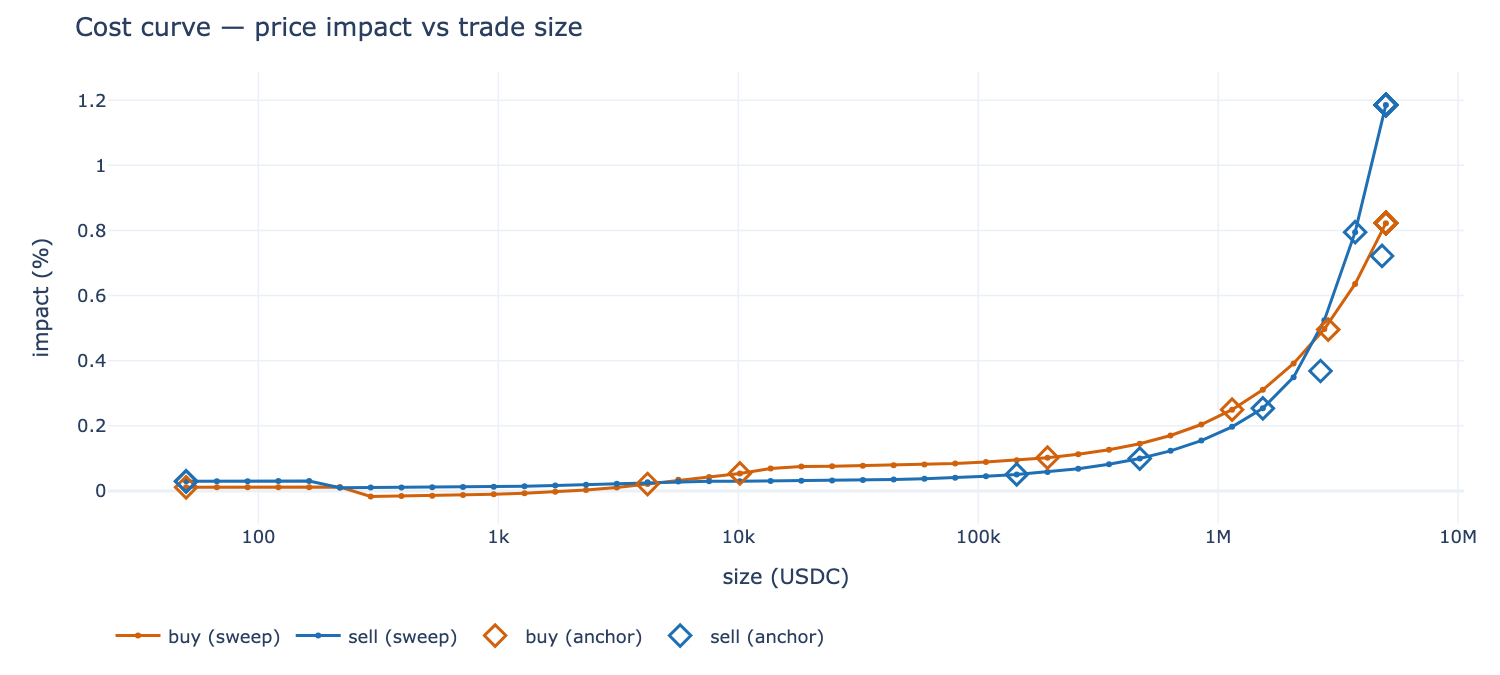

In [6]:
from price_of_ethereum.charts import book_map_figure, cost_curve_figure, spread_curve_figure

cost_curve_figure(rows, numeraire_symbol=NUMERAIRE_SYMBOL).show()

Diamonds are anchored measurements; the line is the bulk sweep. The shaded band
in the book map below is the depth range the robust mid is voted from.

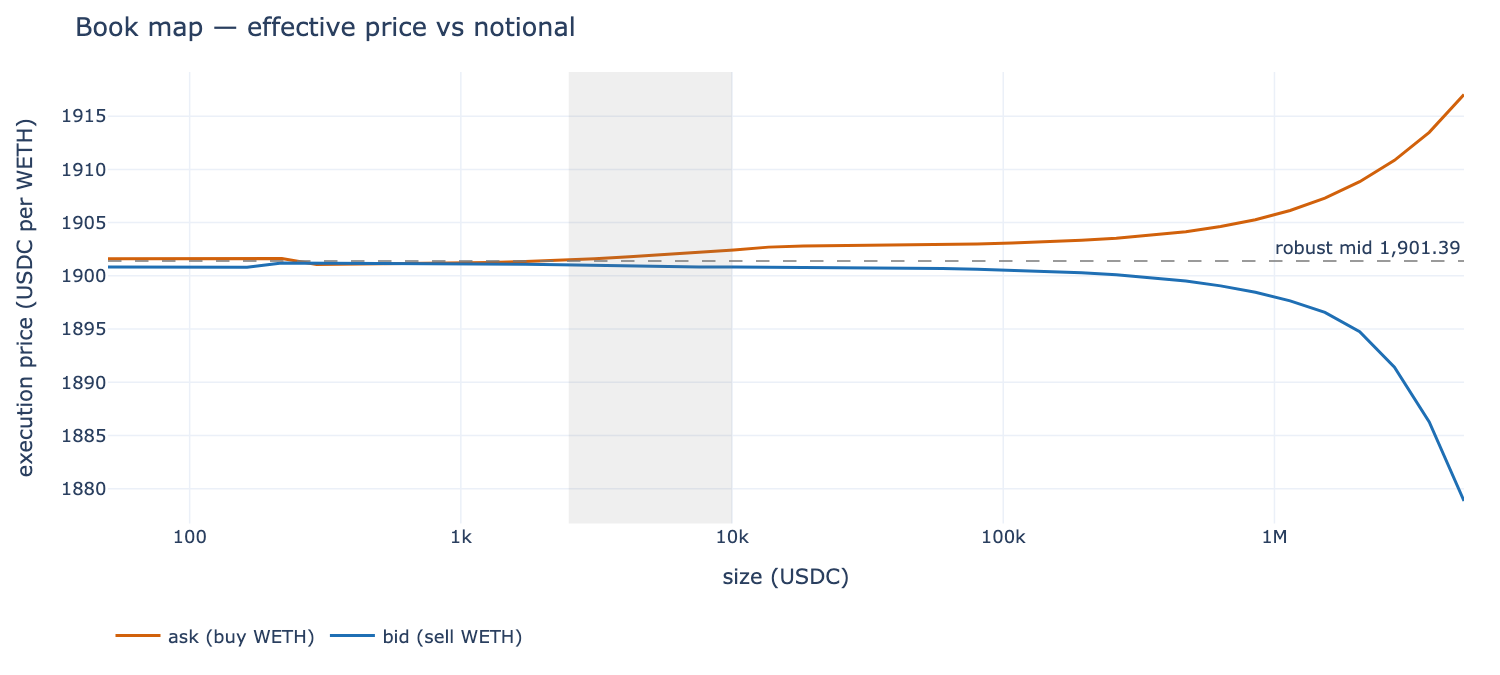

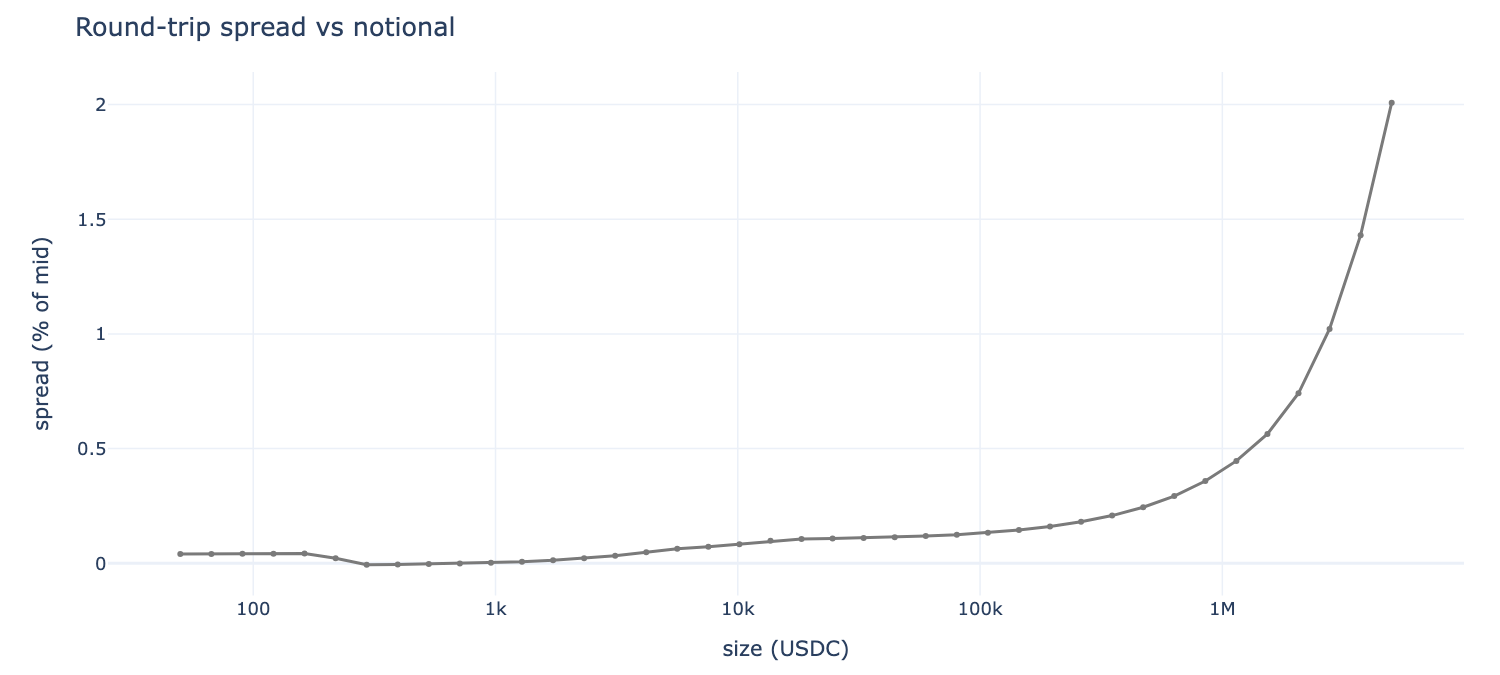

In [7]:
book_map_figure(
    rows,
    snapshot.robust_mid,
    token_symbol=TOKEN_SYMBOL,
    numeraire_symbol=NUMERAIRE_SYMBOL,
    band_min=snapshot.mid_band_min,
    band_max=snapshot.mid_band_max,
).show()
spread_curve_figure(rows, snapshot.robust_mid, numeraire_symbol=NUMERAIRE_SYMBOL).show()

## 5. Where the route changes, and where impact stops being monotonic

`route_hash` fingerprints the set of pools a quote went through, so the sizes
where it changes are the sizes where the router recomposed the trade.

Measured impact does not have to rise with size either: recomposing a route can
make a larger trade cost proportionally *less*, so each negative `impact_delta`
below is a real routing change rather than noise. Against a single deep pool
neither column has anything to show; against real liquidity both usually do.

In [8]:
curve_buy = rows[(rows["kind"] == "curve") & (rows["side"] == "buy")]
buy = curve_buy.sort_values("size_numeraire").copy()
buy["impact_delta"] = buy["impact_pct"].diff()
route_changed = buy["route_hash"] != buy["route_hash"].shift()
buy.loc[
    route_changed | (buy["impact_delta"] < 0),
    ["size_numeraire", "impact_pct", "impact_delta", "n_pools", "protocols", "route_hash"],
]

,size_numeraire,impact_pct,impact_delta,n_pools,protocols,route_hash
0,50.000000,0.011130,NaN,1,[uniswap_v3],0586a4a3bb71e775
6,293.900804,-0.016891,-0.028733,2,"[ekubo_v3, uniswap_v3]",6bcce126bfc188be
16,5626.677910,0.034682,0.013500,1,[uniswap_v3],0586a4a3bb71e775
20,18326.206200,0.074676,0.006141,1,[uniswap_v3],660a51fadc6eb4e4


## 6. Record a history

`collect_blocks` detects a new block by comparing each snapshot's majority block
to the last recorded one. Rows are appended before the block summary, so the
blocks file is the index of blocks whose rows are fully on disk — join against
it.

In [9]:
from price_of_ethereum.collect import collect_blocks

# Its own directory, not `examples/data` — that one holds the committed dataset
# the report is built from, and appending a different sweep to it would mix two
# resolutions into one history.
result = collect_blocks(fynd, config, out_dir="quickstart-data", blocks=10)
result

CollectResult(blocks_recorded=10, rows_written=1160, anchors_written=30, duplicate_snapshots=0, idle_probes=332, failed_cycles=0, interrupted=False, rows_path=PosixPath('quickstart-data/eth-usdc_1.rows.jsonl'), blocks_path=PosixPath('quickstart-data/eth-usdc_1.blocks.jsonl'), anchors_path=PosixPath('quickstart-data/eth-usdc_1.anchors.jsonl'))

In [10]:
from price_of_ethereum import load_jsonl, load_parquet, to_parquet
from price_of_ethereum.charts import history_health_figure, history_mid_figure

recorded = load_jsonl(result.blocks_path)
recorded_at = pd.to_datetime(recorded["block_timestamp"], unit="s", utc=True)
print(
    f"{PAIR} on chain {chain_id}: blocks {recorded['block_number'].min()}"
    f" to {recorded['block_number'].max()}, "
    f"{recorded_at.min():%Y-%m-%d %H:%M:%S} to {recorded_at.max():%H:%M:%S} UTC"
)
summary_columns = [
    "block_number",
    "spot",
    "robust_mid",
    "median_depth",
    "mid_source",
    "mixed_block",
    "duration_ms",
]
recorded[summary_columns]

ETH/USDC on chain 1: blocks 25638143 to 25638752, 2026-07-29 11:18:47 to 13:20:35 UTC


,block_number,spot,robust_mid,median_depth,mid_source,mixed_block,duration_ms
0,25638143,1912.465486,1912.35891,4188.38820,sweep_band,False,2035
1,25638144,1912.457277,1912.35481,4188.38820,sweep_band,False,1950
2,25638145,1912.488591,1912.37047,4188.38820,sweep_band,False,1757
3,25638146,1912.488591,1912.36981,4188.38820,sweep_band,False,3179
4,25638147,1911.219116,1911.14844,5626.67791,sweep_band,False,2779
5,25638148,1910.506193,1910.42551,5626.67791,sweep_band,False,2586
6,25638149,1911.464598,1911.39889,3117.75367,sweep_band,False,2891
7,25638150,1912.010703,1911.65229,4188.38820,sweep_band,False,2915
8,25638151,1912.442389,1912.02547,5626.67791,sweep_band,False,2264
9,25638152,1912.512720,1912.10263,4188.38820,sweep_band,False,2095


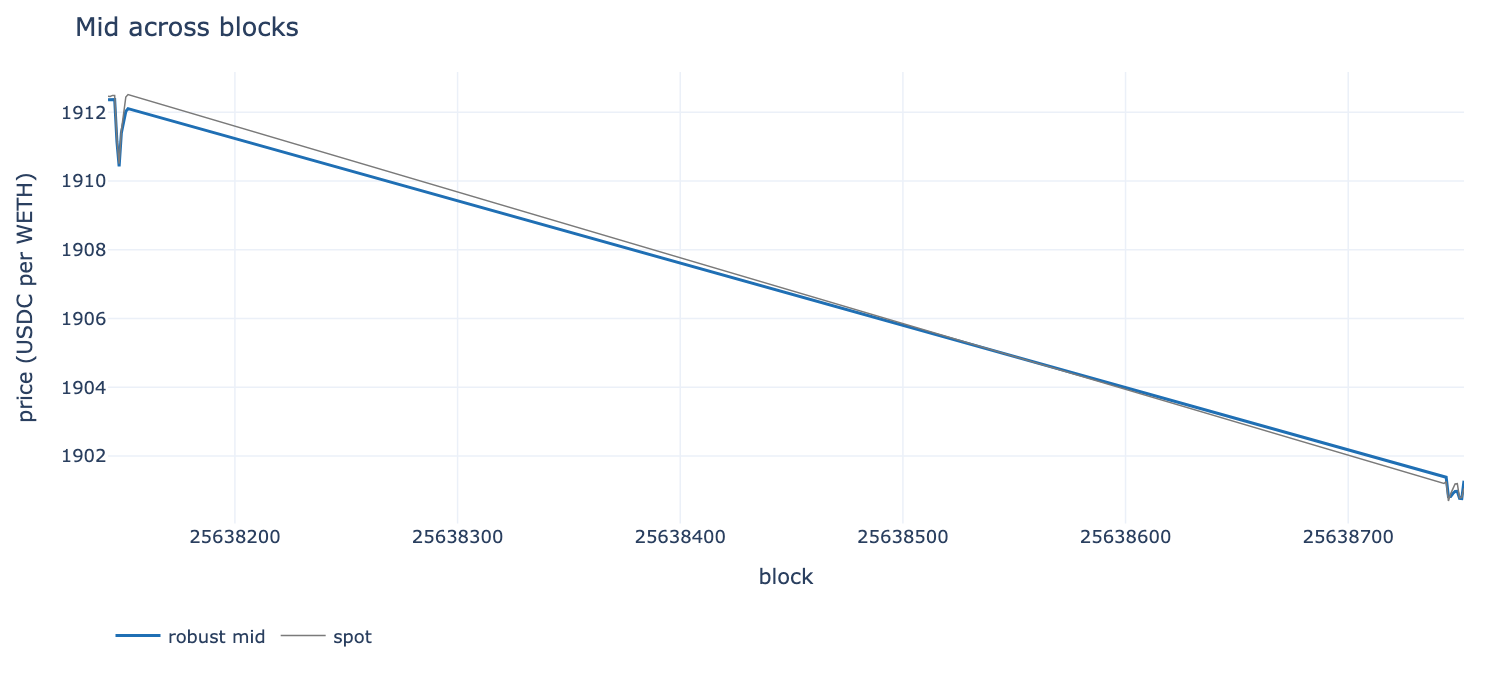

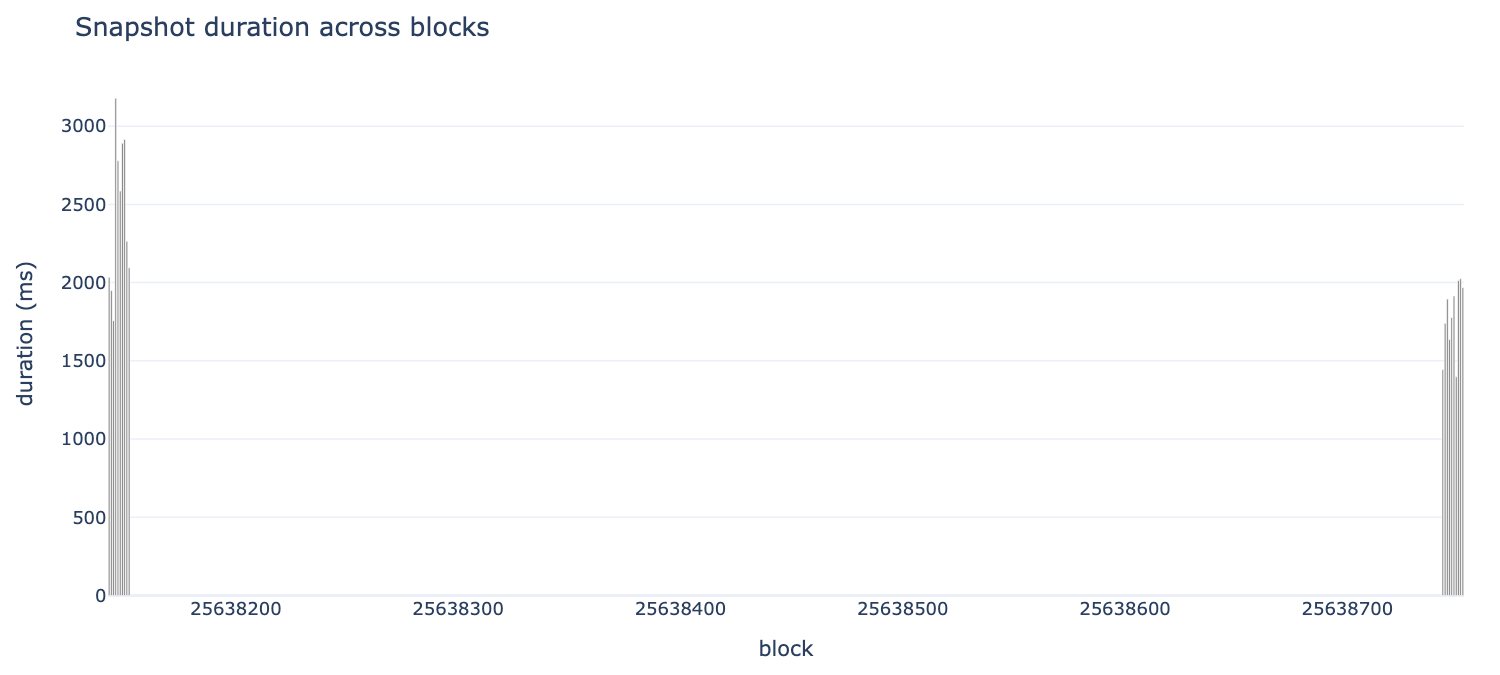

In [11]:
history_mid_figure(recorded, token_symbol=TOKEN_SYMBOL, numeraire_symbol=NUMERAIRE_SYMBOL).show()
history_health_figure(recorded).show()  # bars colored where mixed_block fired

JSONL is the collection format; parquet is the analysis format.

In [12]:
all_rows = load_jsonl(result.rows_path)
parquet_path = result.rows_path.with_suffix(".parquet")  # …rows.jsonl -> …rows.parquet
to_parquet(all_rows, parquet_path)
load_parquet(parquet_path).groupby(["block_number", "kind"]).size().head()

block_number  kind  
25638143      anchor    36
              curve     80
25638144      anchor    36
              curve     80
25638145      anchor    36
dtype: int64

## 7. Or keep measuring

To keep a history running without re-running this notebook, leave the collector
going and read what it has recorded:

```bash
poe collect --out data      # append a row per block until interrupted
```

`load_jsonl` reads those files back at any point, and the charts above redraw
from them — the recorded JSONL is the full dataset, so nothing here is the only
copy of anything.

[`examples/data`](./data) is a committed one: ETH/USDC on Ethereum mainnet over
twelve blocks, with a note beside it saying exactly what was measured and when.
